### Unsupervised Learning: Density Based Methods

#### DBSCAN Implementation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [9]:
X, y_true = make_classification(
    n_samples = 500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    n_classes=3,
    random_state=42
)

In [6]:
X_scaled = StandardScaler().fit_transform(X)

In [16]:
epsilon = 0.2
min_samples = 5

dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

print(labels)

[ 0  0  0  0  0  0 -1  0  0  0  0  2  0  0  0  0  0  0  0  0  0  0  0 -1
  0  0  0  0  0  0  0  0  0  0 -1  0 -1 -1  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 -1  0  0 -1  0  0 -1  0  0  0  2  0  0  0  0
  0  0  0  0  0  2  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  1  0  0  0  0 -1  0  0  0  0
 -1  0  0  0  0  0 -1  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0 -1  0  0  0  0  0  0  0  0
  0 -1  0  0  0  0  0 -1  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0
  0 -1 -1 -1  0  0  0  0  0  0  0  0  0  0  0  2  0  0  0  0  0  0 -1  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0  0  0  0  0  0
 -1  0  0  0  0  0  1  0 -1  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0
  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0 -1  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  2  0
  0 -1  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0

In [17]:
n_clusters = len(set(labels)) - (1 if -1 in set(labels) else 0)

print(n_clusters)

3


C:\Users\Dianne Yumol\AppData\Local\Temp\ipykernel_9416\2090413103.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(xy[:,0], xy[:,1], c=col, label=label)


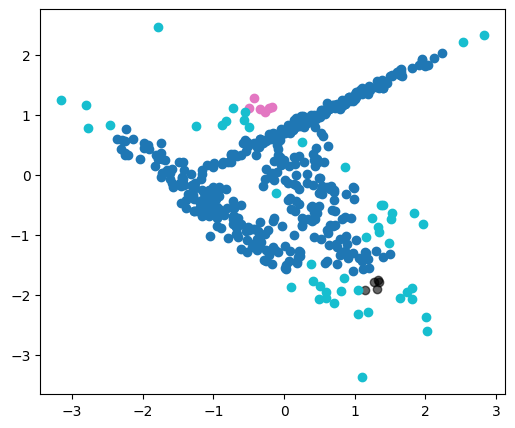

In [18]:
plt.figure(figsize=(6,5))
unique_labels = set(labels)
colors = [plt.cm.tab10(each) for each in np.linspace(0,1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == 1:
        col = [0, 0, 0, 0.6]
        label = 'Noise'
    else:
        label = f"Cluster {k}"

    mask = (labels == k)
    xy = X_scaled[mask]

    plt.scatter(xy[:,0], xy[:,1], c=col, label=label)

plt.show()

In [19]:
epsilons = [0.2, 0.4, 0.6, 0.8]

for eps in epsilons:
    db = DBSCAN(eps = eps, min_samples=min_samples)
    db.fit(X_scaled)
    labels = db.labels_
    score = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else -1
    print(f"eps={eps} clusters={len(set(labels))} score={score}")

eps=0.2 clusters=4 score=-0.1968666307046042
eps=0.4 clusters=2 score=0.4770520467289203
eps=0.6 clusters=2 score=0.5093047997483025
eps=0.8 clusters=2 score=0.49457968288688403
